In [1]:
import pandas as pd
import numpy as np
from joblib import Parallel, delayed
from contextlib import contextmanager
import joblib
from tqdm import tqdm
import os
import pathlib
tqdm.pandas()

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
from matplotlib.patches import Ellipse, Circle
import seaborn as sns

from scipy.stats import ttest_rel, ttest_ind, mannwhitneyu, wilcoxon, binomtest

pd.set_option('display.max_rows', 500)

from IPython.display import HTML

In [2]:
def do_btest(strat):
    # Lets now do the binomial tests for the strategy against a1 and a2
    btest = []
    for i in range(len(strat)):
        n = strat.iloc[i].a1 + strat.iloc[i].a2
        btest.append(binomtest(strat.iloc[i].a1, n, 0.5, alternative="two-sided").pvalue)
    return np.array(btest)

## Training

In [3]:

base= "../store_bk"
trains = sorted(os.listdir(base))

strat_1 = []
strat_2 = []
strat_3 = []

train_tt = []

for i in tqdm(trains[:]):
    f = f"{base}/{i}/trial_stats/training_1.parquet"
    t = pd.read_parquet(f)
    train_tt.append(t.trial_id.max())
    strat_1.append(t.activated_by.value_counts().to_dict())
    strat_2.append(t.first_close_to_zone.value_counts().to_dict())
    strat_3.append(t.first_to_zone.value_counts().to_dict())

100%|██████████| 200/200 [00:36<00:00,  5.42it/s]


In [4]:
train_strats = (strat_1, strat_2, strat_3)

cols = ["a1", "a2", "tie"]
strat_1 = pd.DataFrame(strat_1, columns=cols)
strat_2 = pd.DataFrame(strat_2, columns=cols)
strat_3 = pd.DataFrame(strat_3, columns=cols)


# add 0 to missing values and make all columns into int
strat_1 = strat_1.fillna(0).astype(int)
strat_2 = strat_2.fillna(0).astype(int)
strat_3 = strat_3.fillna(0).astype(int)

s1_btest = pd.Series(do_btest(strat_1), name="pval")
s2_btest = pd.Series(do_btest(strat_2), name="pval")
s3_btest = pd.Series(do_btest(strat_3), name="pval")

l1 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_1.to_dict(orient="records")]
f1 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_1.to_dict(orient="records")]

l2 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_2.to_dict(orient="records")]
f2 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_2.to_dict(orient="records")]

train_sig = pd.DataFrame({
    "l1": [ strat_1.iloc[i][l1[i]] for i in range(len(l1))],
    "f1": [ strat_1.iloc[i][f1[i]] for i in range(len(f1))],
    "s1": s1_btest,
    "l2": [ strat_2.iloc[i][l2[i]] for i in range(len(l2))],
    "f2": [ strat_2.iloc[i][f2[i]] for i in range(len(f2))],
    "s2": s2_btest,
})

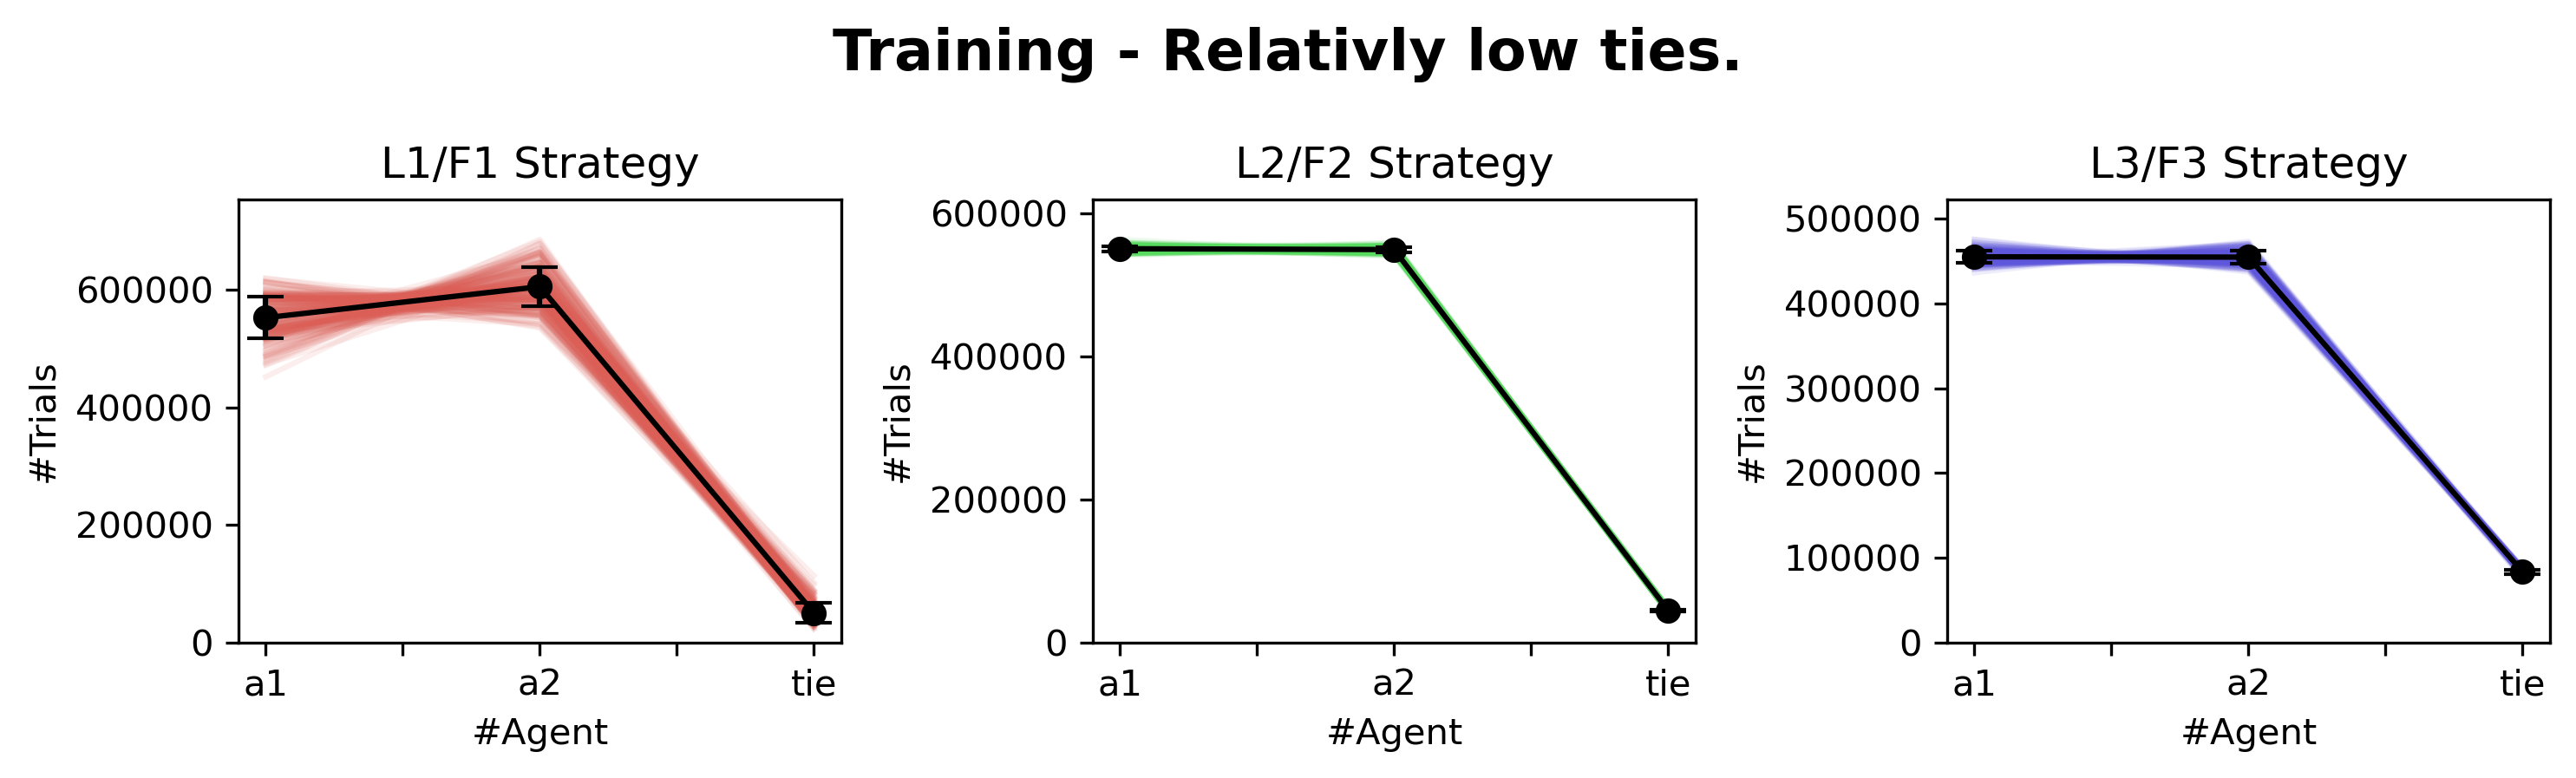

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3), dpi=300)

mycols = sns.hls_palette(n_colors=3, h=0.01, l=0.6, s=0.65, as_cmap=False)

for i in range(len(strat_1)):
    strat_1.iloc[i].plot(ax=ax[0], color=mycols[0], alpha=0.1)
    strat_2.iloc[i].plot(ax=ax[1], color=mycols[1], alpha=0.1)
    strat_3.iloc[i].plot(ax=ax[2], color=mycols[2], alpha=0.1)

strat_1.mean().plot(ax=ax[0], color="k")
strat_2.mean().plot(ax=ax[1], color="k")
strat_3.mean().plot(ax=ax[2], color="k")
for i in range(len(strat_1.mean())):
    ax[0].errorbar(i, strat_1.mean().iloc[i], yerr=strat_1.std().iloc[i], fmt='o', color='black', capsize=5)
    ax[1].errorbar(i, strat_2.mean().iloc[i], yerr=strat_2.std().iloc[i], fmt='o', color='black', capsize=5)
    ax[2].errorbar(i, strat_3.mean().iloc[i], yerr=strat_3.std().iloc[i], fmt='o', color='black', capsize=5)

ax[0].set_title("L1/F1 Strategy")
ax[0].set_ylabel("#Trials")
ax[0].set_xlabel("#Agent")
ax[0].set_ylim(0, strat_1.max().max()*1.1)
ax[1].set_title("L2/F2 Strategy")
ax[1].set_ylabel("#Trials")
ax[1].set_xlabel("#Agent")
ax[1].set_ylim(0, strat_2.max().max()*1.1)
ax[2].set_title("L3/F3 Strategy")
ax[2].set_ylabel("#Trials")
ax[2].set_xlabel("#Agent")
ax[2].set_ylim(0, strat_3.max().max()*1.1)

plt.suptitle("Training - Relativly low ties.", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()


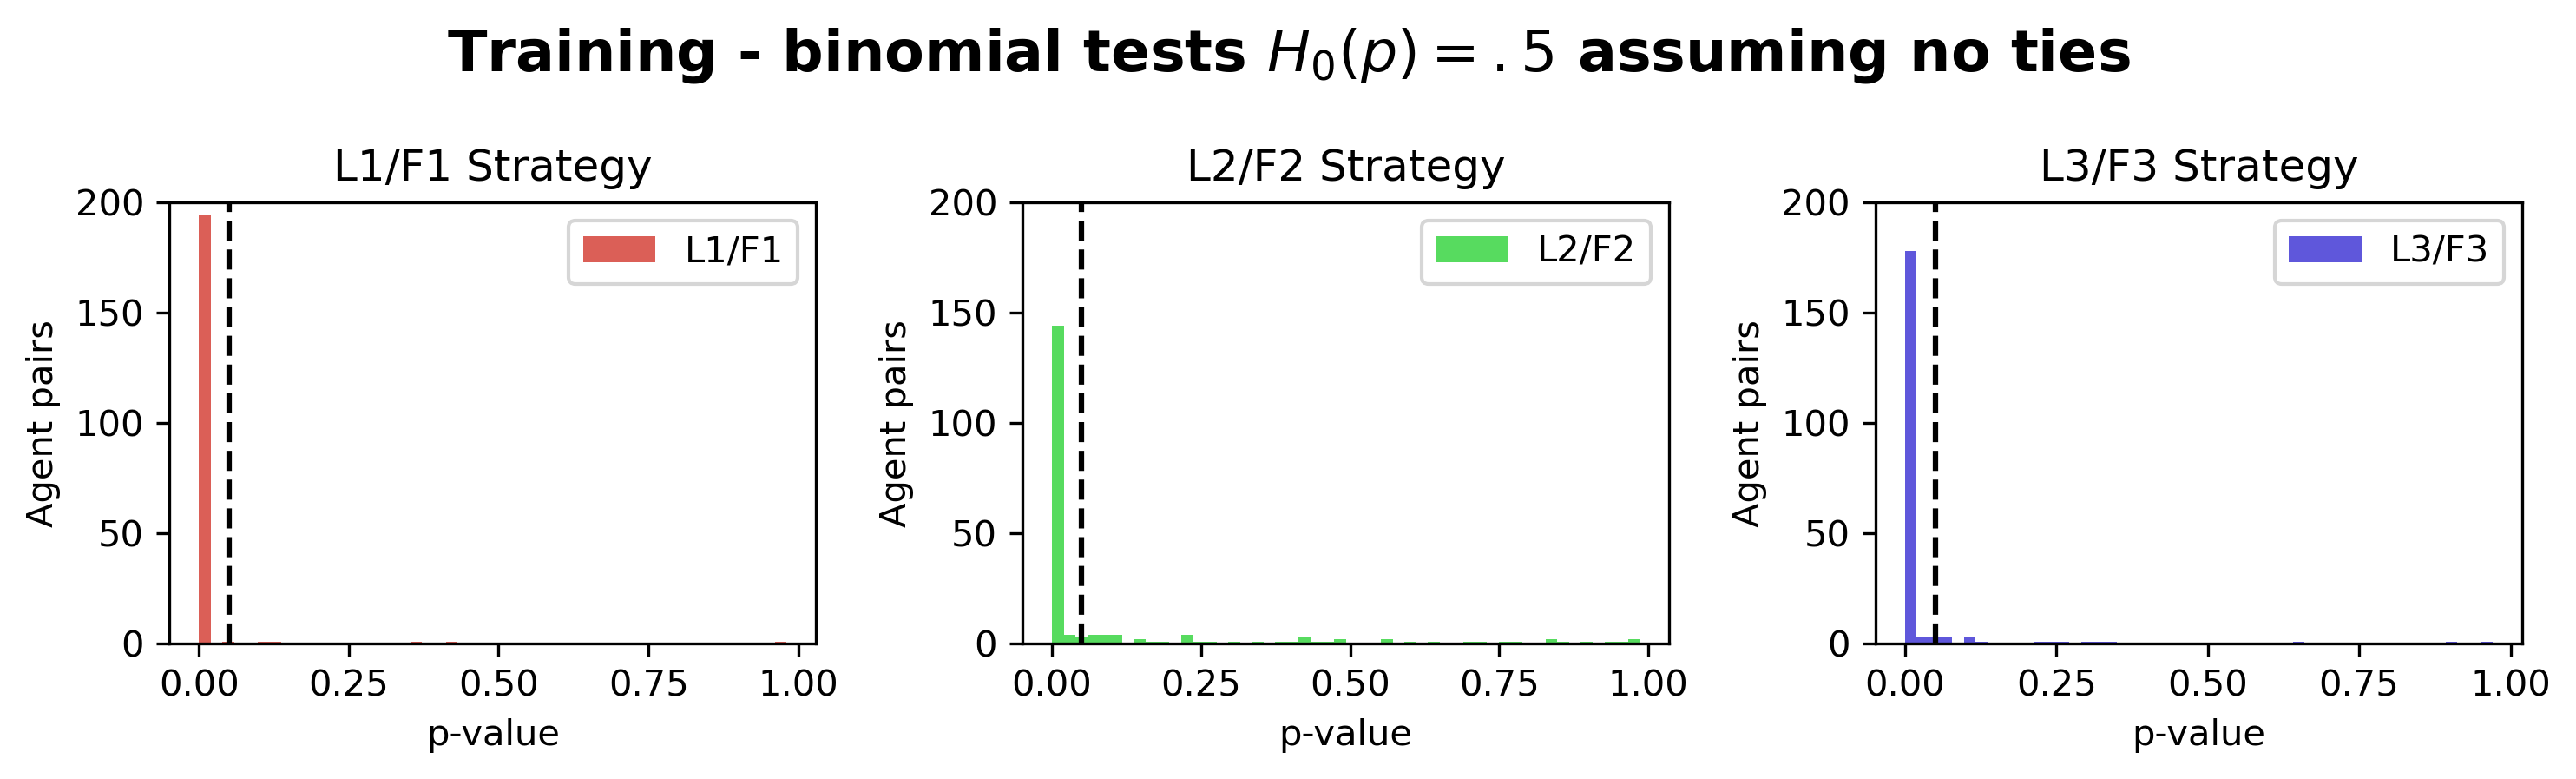

In [6]:
# Plot the counts of the binomial tests with pvalues < 0.05 for each strategy


s1_btest[s1_btest < 0.05].count(), s2_btest[s2_btest < 0.05].count(), s3_btest[s3_btest < 0.05].count()
# Plot the counts of the binomial tests with pvalues < 0.05 for each strategy
fig, ax = plt.subplots(1, 3, figsize=(10, 3), dpi=300)
s1_btest.plot.hist(ax=ax[0], bins=50, alpha=1, color=mycols[0], label="L1/F1")
s2_btest.plot.hist(ax=ax[1], bins=50, alpha=1, color=mycols[1], label="L2/F2")
s3_btest.plot.hist(ax=ax[2], bins=50, alpha=1, color=mycols[2], label="L3/F3")
titles = ["L1/F1 Strategy", "L2/F2 Strategy", "L3/F3 Strategy"]
for i in range(3):
    ax[i].axvline(0.05, color='k', linestyle='--')
    ax[i].set_xlabel("p-value")
    ax[i].set_ylabel("Agent pairs")
    ax[i].set_title(titles[i])
    ax[i].legend()
    ax[i].set_ylim(0, 200)
plt.suptitle("Training - binomial tests $H_0(p)=.5$ assuming no ties", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()


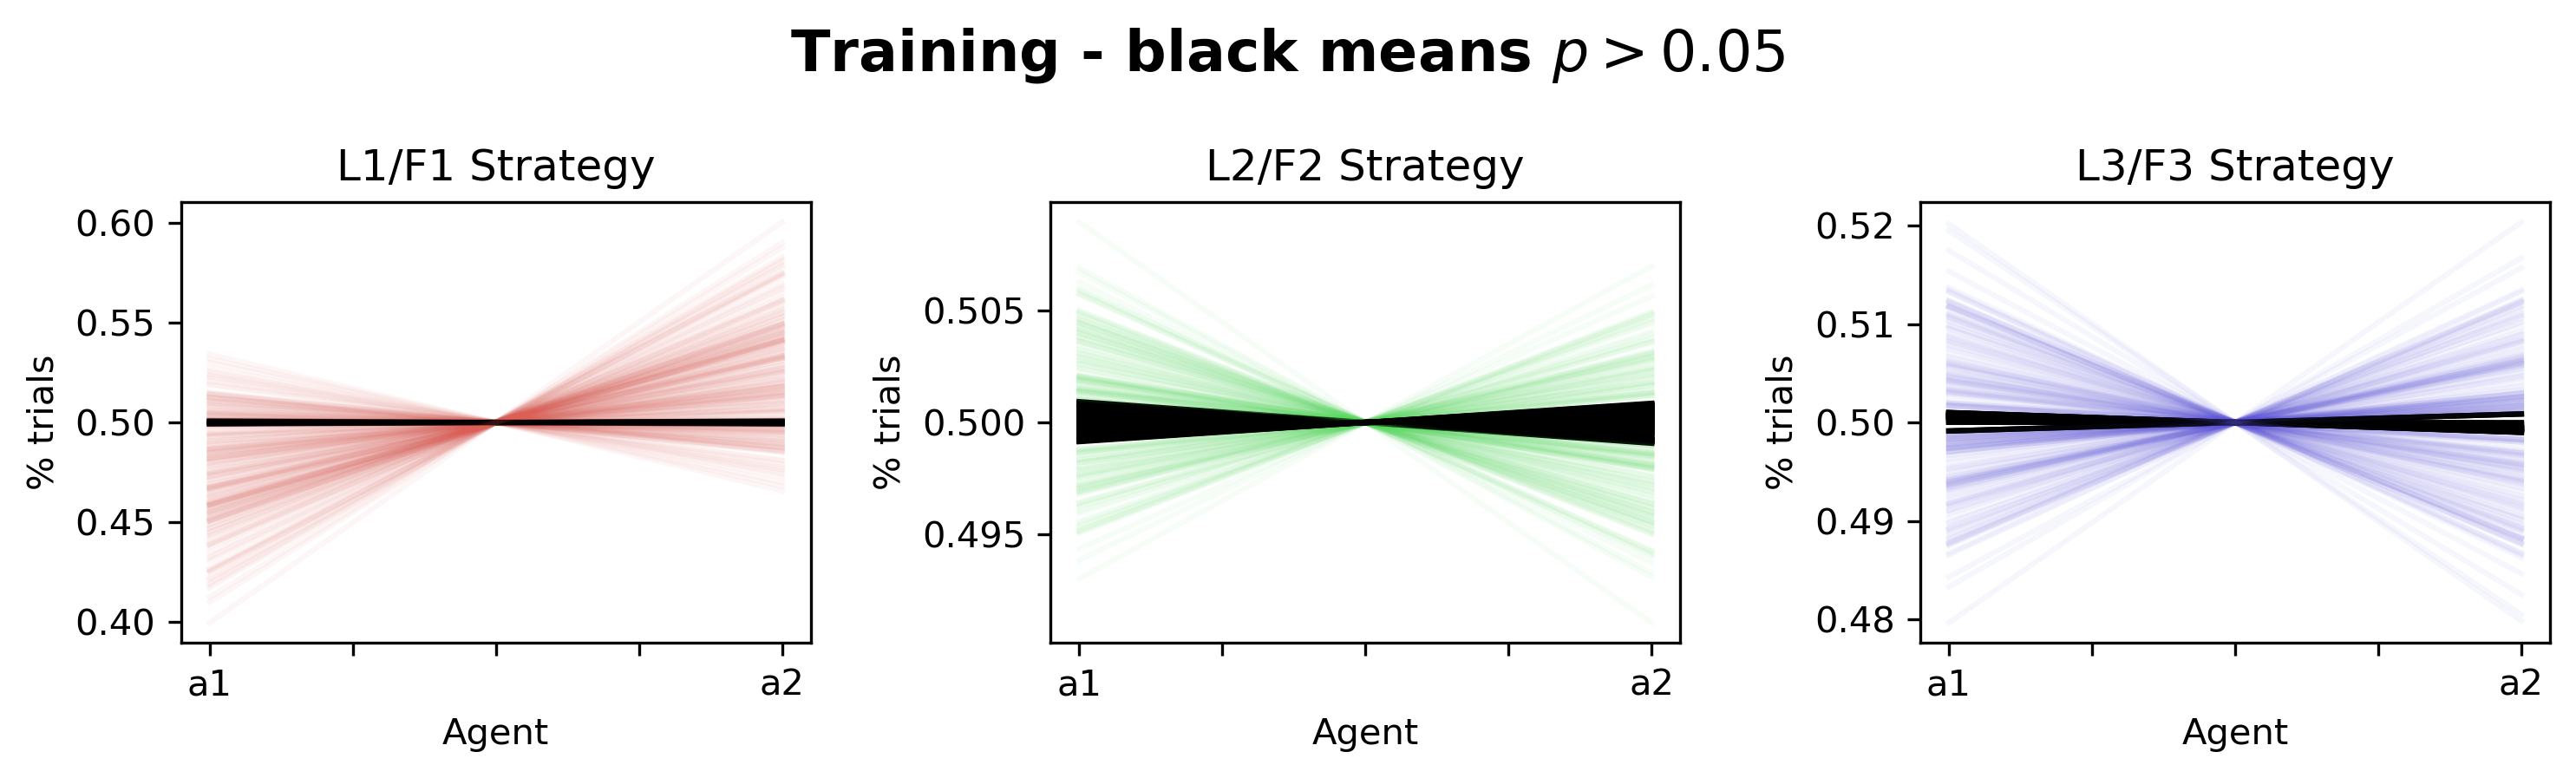

In [7]:
# Now the same thing but lets only visualize the a1 and a2 in the 3 strategies
# and also lets normalize the data to the number of trials (a1 + a2)

ns1 = strat_1[["a1", "a2"]] / strat_1[["a1", "a2"]].sum(axis=1).values[:, None]
ns2 = strat_2[["a1", "a2"]] / strat_2[["a1", "a2"]].sum(axis=1).values[:, None]
ns3 = strat_3[["a1", "a2"]] / strat_3[["a1", "a2"]].sum(axis=1).values[:, None]
insig_color = "black"
fig, ax = plt.subplots(1, 3, figsize=(10, 3), dpi=300)
for i in range(len(ns1)):
    significant = s1_btest[i] < 0.05
    color = mycols[0] if significant else insig_color
    alpha = 0.05 if significant else 1
    label = "significant" if significant else "insignificant"
    ns1.iloc[i].plot(ax=ax[0], color=color, alpha=alpha, label=label)
    
    color = mycols[1] if s2_btest[i] < 0.05 else insig_color
    alpha = 0.05 if s2_btest[i] < 0.05 else 1
    label = "significant" if s2_btest[i] < 0.05 else "insignificant"
    ns2.iloc[i].plot(ax=ax[1], color=color, alpha=alpha, label=label)
    
    color = mycols[2] if s3_btest[i] < 0.05 else insig_color
    alpha = 0.05 if s3_btest[i] < 0.05 else 1
    label = "significant" if s3_btest[i] < 0.05 else "insignificant"
    ns3.iloc[i].plot(ax=ax[2], color=color, alpha=alpha, label=label)

for i in range(3):
    ax[i].set_xlabel("Agent")
    ax[i].set_ylabel("% trials")
    ax[i].set_title(titles[i])

plt.suptitle("Training - black means $p>0.05$", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

## Testing

In [8]:

base= "../store_bk"
trains = sorted(os.listdir(base))

strat_1 = []
strat_2 = []
strat_3 = []

train_tt = []

for i in tqdm(trains[:]):
    f = f"{base}/{i}/trial_stats/testing_1.parquet"
    t = pd.read_parquet(f)
    train_tt.append(t.trial_id.max())
    strat_1.append(t.activated_by.value_counts().to_dict())
    strat_2.append(t.first_close_to_zone.value_counts().to_dict())
    strat_3.append(t.first_to_zone.value_counts().to_dict())

100%|██████████| 200/200 [00:04<00:00, 49.53it/s]


In [9]:
test_strats = (strat_1, strat_2, strat_3)

cols = ["a1", "a2", "tie"]
strat_1 = pd.DataFrame(strat_1, columns=cols)
strat_2 = pd.DataFrame(strat_2, columns=cols)
strat_3 = pd.DataFrame(strat_3, columns=cols)

strat_1 = strat_1.fillna(0).astype(int)
strat_2 = strat_2.fillna(0).astype(int)
strat_3 = strat_3.fillna(0).astype(int)

s1_btest = pd.Series(do_btest(strat_1), name="pval")
s2_btest = pd.Series(do_btest(strat_2), name="pval")
s3_btest = pd.Series(do_btest(strat_3), name="pval")

l1 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_1.to_dict(orient="records")]
f1 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_1.to_dict(orient="records")]

l2 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_2.to_dict(orient="records")]
f2 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_2.to_dict(orient="records")]

l3 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_3.to_dict(orient="records")]
f3 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_3.to_dict(orient="records")]

test_sig = pd.DataFrame({
    "l1": [ strat_1.iloc[i][l1[i]] for i in range(len(l1))],
    "f1": [ strat_1.iloc[i][f1[i]] for i in range(len(f1))],
    "s1": s1_btest,
    "l2": [ strat_2.iloc[i][l2[i]] for i in range(len(l2))],
    "f2": [ strat_2.iloc[i][f2[i]] for i in range(len(f2))],
    "s2": s2_btest,
    "l3": [ strat_3.iloc[i][l3[i]] for i in range(len(l3))],
    "f3": [ strat_3.iloc[i][f3[i]] for i in range(len(f3))],
    "s3": s3_btest,
})

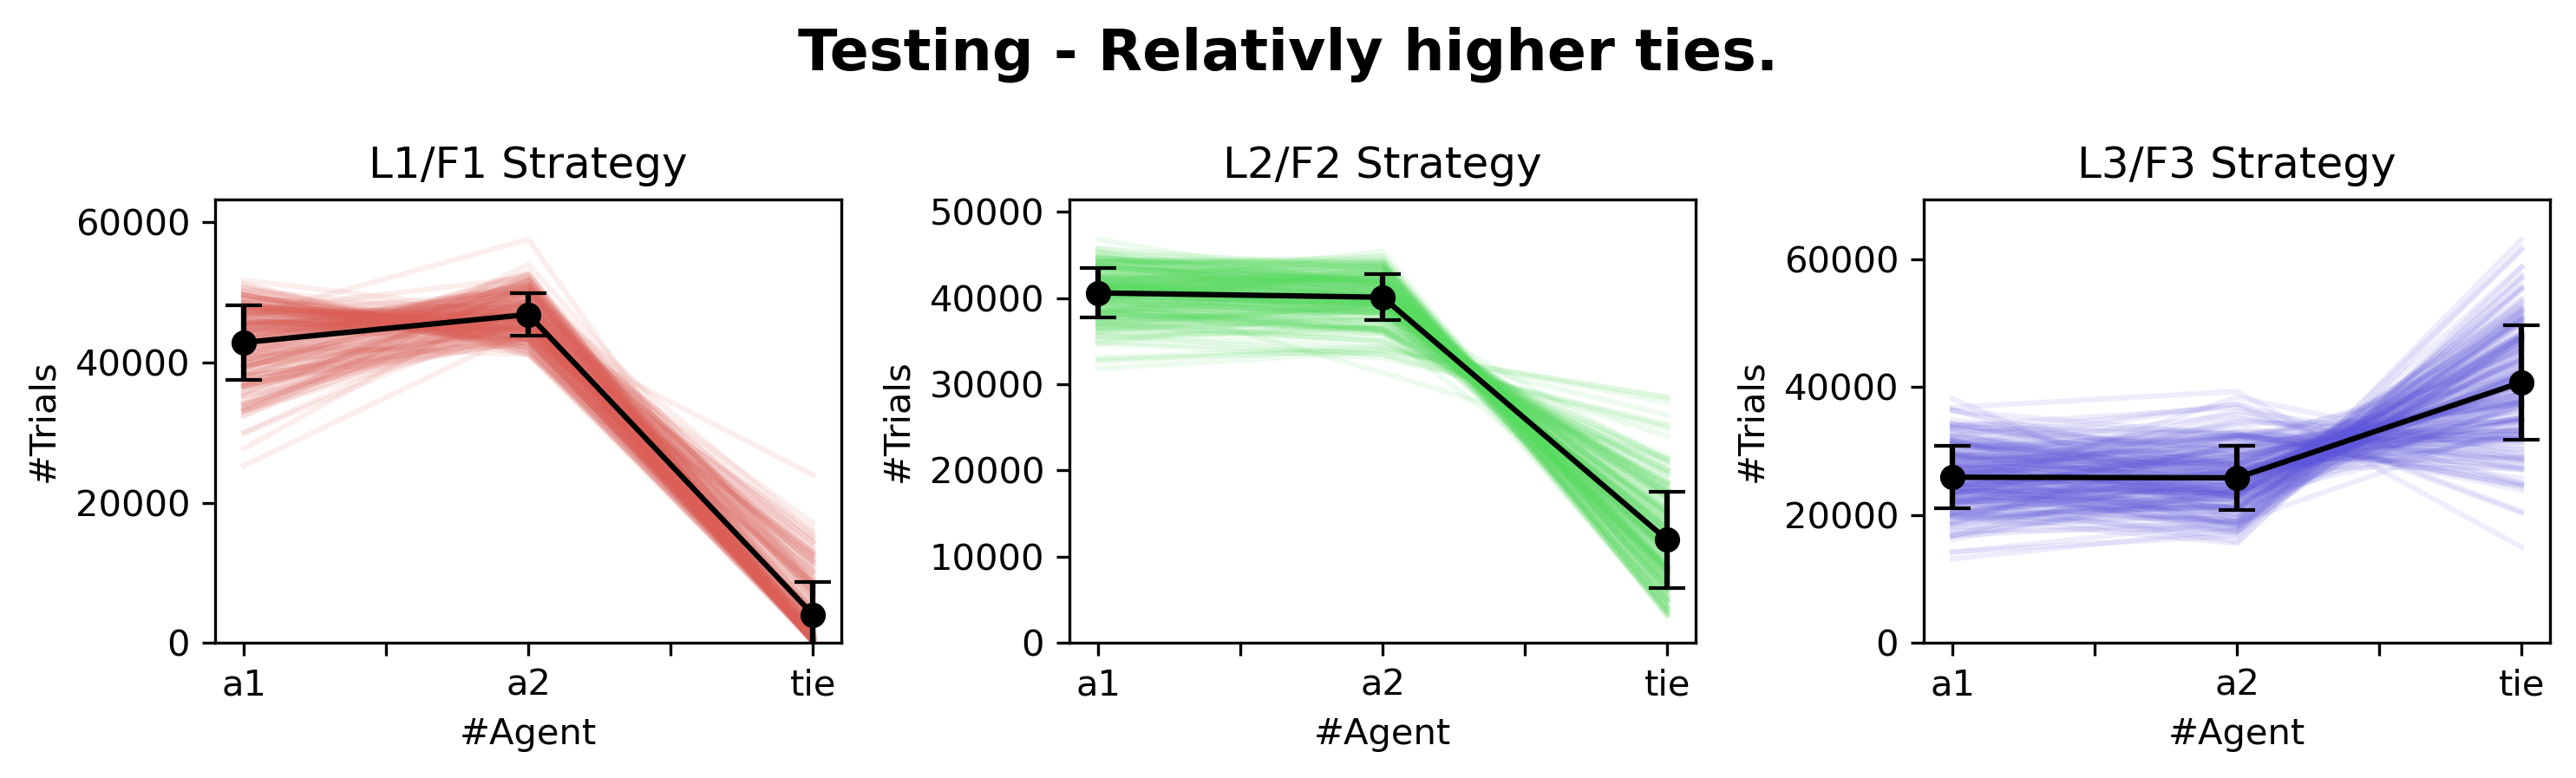

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3), dpi=300)

mycols = sns.hls_palette(n_colors=3, h=0.01, l=0.6, s=0.65, as_cmap=False)

for i in range(len(strat_1)):
    strat_1.iloc[i].plot(ax=ax[0], color=mycols[0], alpha=0.1)
    strat_2.iloc[i].plot(ax=ax[1], color=mycols[1], alpha=0.1)
    strat_3.iloc[i].plot(ax=ax[2], color=mycols[2], alpha=0.1)

strat_1.mean().plot(ax=ax[0], color="k")
strat_2.mean().plot(ax=ax[1], color="k")
strat_3.mean().plot(ax=ax[2], color="k")
for i in range(len(strat_1.mean())):
    ax[0].errorbar(i, strat_1.mean().iloc[i], yerr=strat_1.std().iloc[i], fmt='o', color='black', capsize=5)
    ax[1].errorbar(i, strat_2.mean().iloc[i], yerr=strat_2.std().iloc[i], fmt='o', color='black', capsize=5)
    ax[2].errorbar(i, strat_3.mean().iloc[i], yerr=strat_3.std().iloc[i], fmt='o', color='black', capsize=5)

ax[0].set_title("L1/F1 Strategy")
ax[0].set_ylabel("#Trials")
ax[0].set_xlabel("#Agent")
ax[0].set_ylim(0, strat_1.max().max()*1.1)
ax[1].set_title("L2/F2 Strategy")
ax[1].set_ylabel("#Trials")
ax[1].set_xlabel("#Agent")
ax[1].set_ylim(0, strat_2.max().max()*1.1)
ax[2].set_title("L3/F3 Strategy")
ax[2].set_ylabel("#Trials")
ax[2].set_xlabel("#Agent")
ax[2].set_ylim(0, strat_3.max().max()*1.1)

plt.suptitle("Testing - Relativly higher ties.", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()


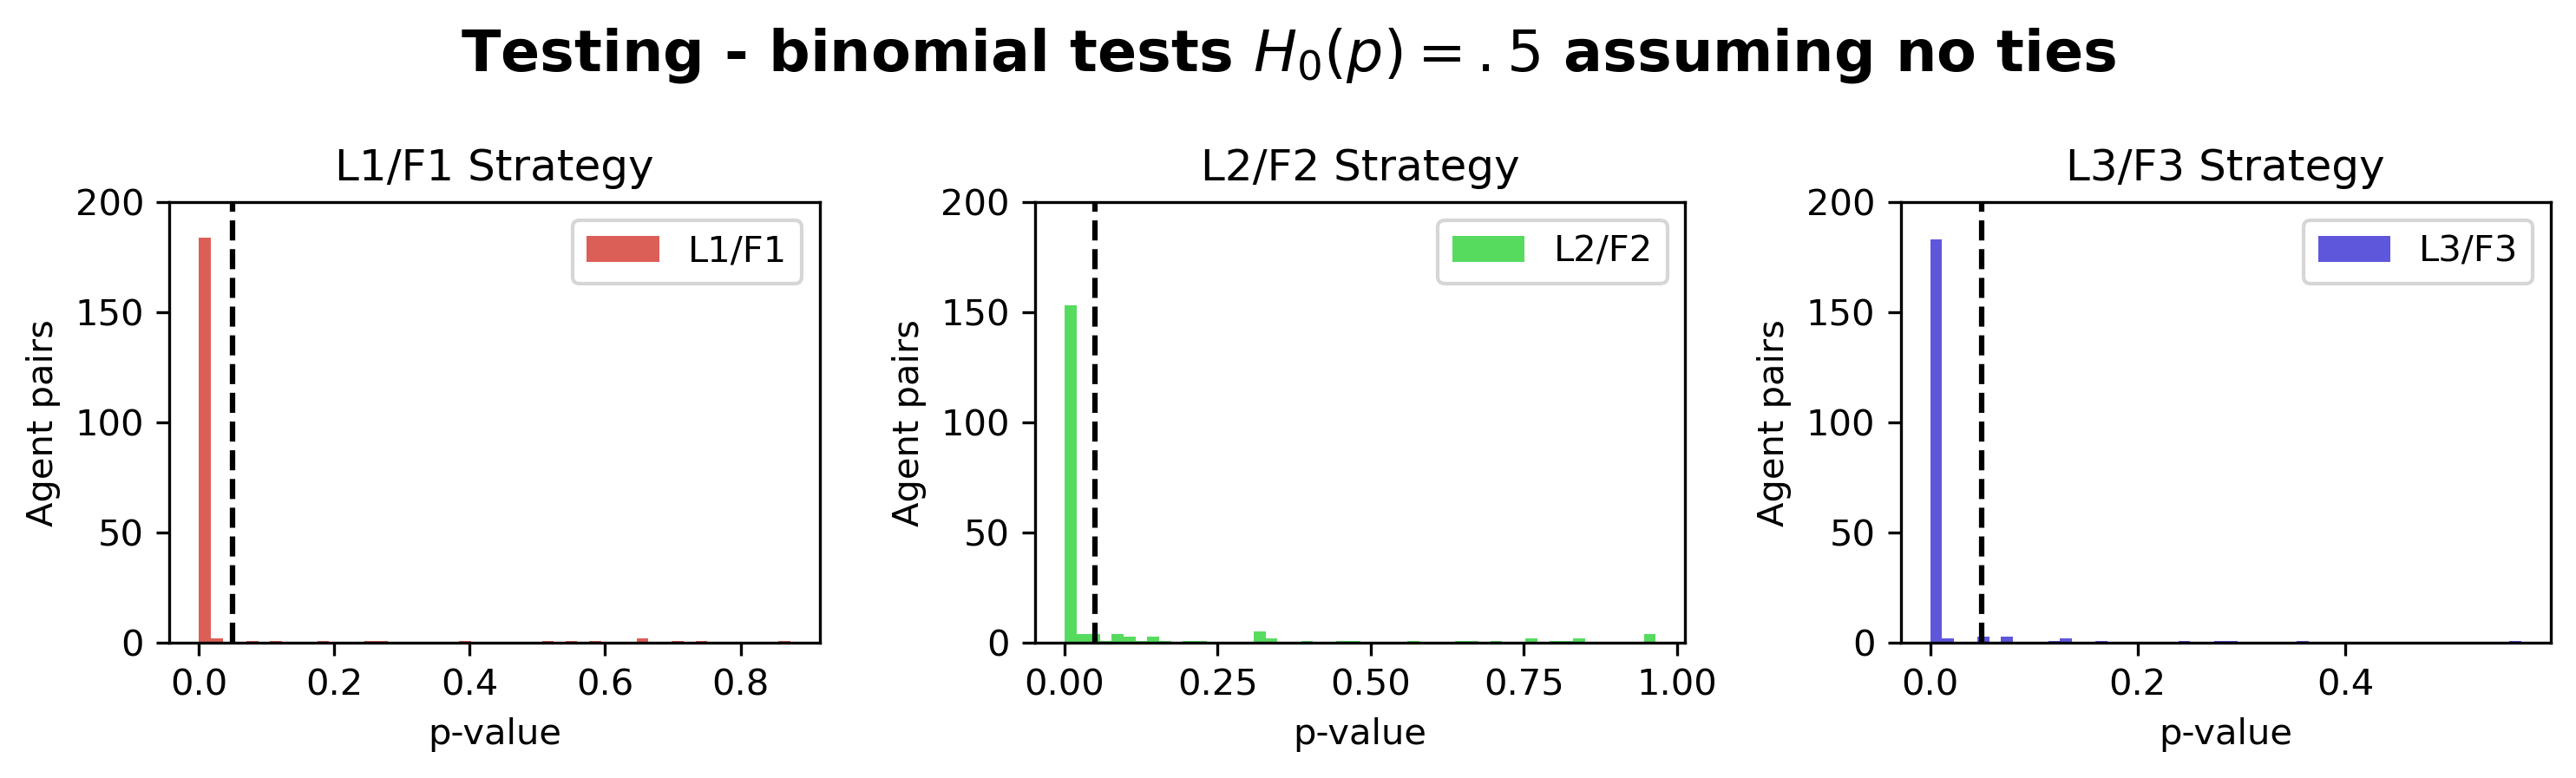

In [11]:
# Plot the counts of the binomial tests with pvalues < 0.05 for each strategy

s1_btest[s1_btest < 0.05].count(), s2_btest[s2_btest < 0.05].count(), s3_btest[s3_btest < 0.05].count()
# Plot the counts of the binomial tests with pvalues < 0.05 for each strategy
fig, ax = plt.subplots(1, 3, figsize=(10, 3), dpi=300)
s1_btest.plot.hist(ax=ax[0], bins=50, alpha=1, color=mycols[0], label="L1/F1")
s2_btest.plot.hist(ax=ax[1], bins=50, alpha=1, color=mycols[1], label="L2/F2")
s3_btest.plot.hist(ax=ax[2], bins=50, alpha=1, color=mycols[2], label="L3/F3")
titles = ["L1/F1 Strategy", "L2/F2 Strategy", "L3/F3 Strategy"]
for i in range(3):
    ax[i].axvline(0.05, color='k', linestyle='--')
    ax[i].set_xlabel("p-value")
    ax[i].set_ylabel("Agent pairs")
    ax[i].set_title(titles[i])
    ax[i].legend()
    ax[i].set_ylim(0, 200)
plt.suptitle("Testing - binomial tests $H_0(p)=.5$ assuming no ties", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()


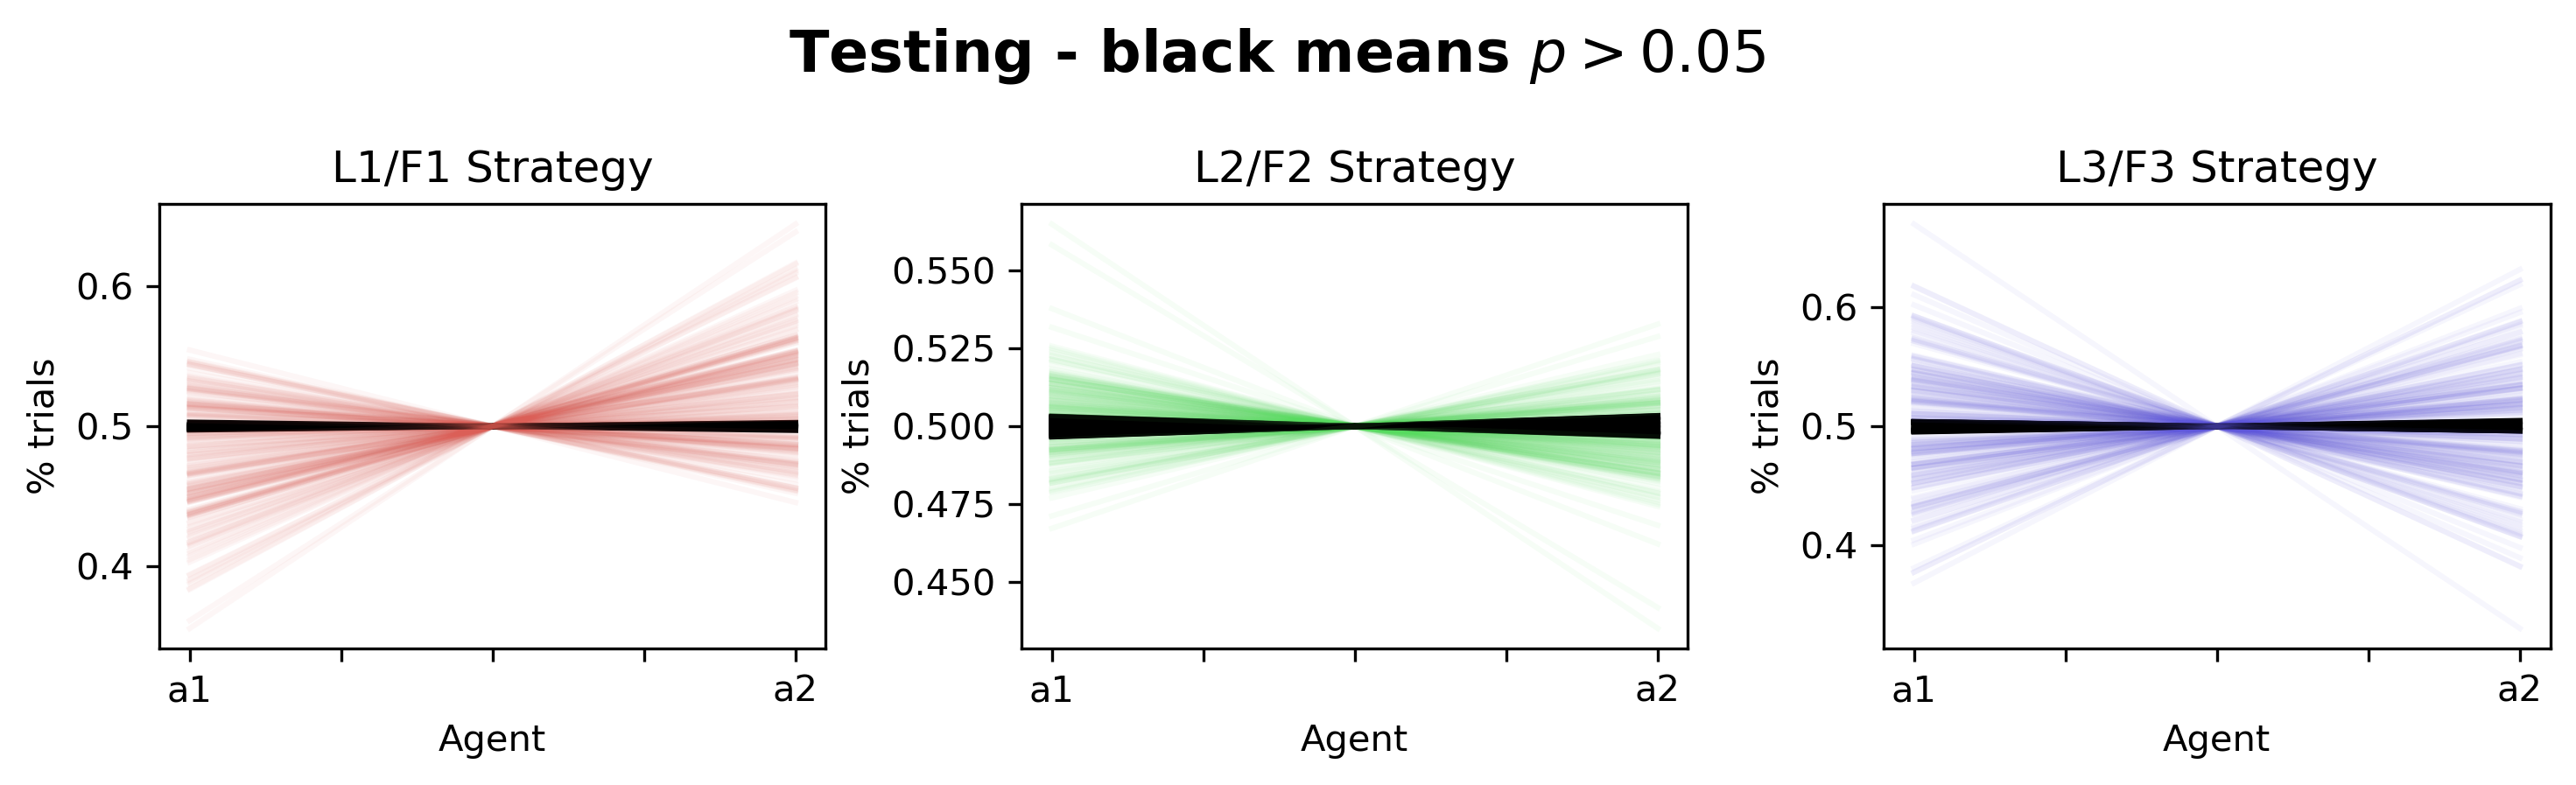

In [12]:
# Now the same thing but lets only visualize the a1 and a2 in the 3 strategies
# and also lets normalize the data to the number of trials (a1 + a2)

ns1 = strat_1[["a1", "a2"]] / strat_1[["a1", "a2"]].sum(axis=1).values[:, None]
ns2 = strat_2[["a1", "a2"]] / strat_2[["a1", "a2"]].sum(axis=1).values[:, None]
ns3 = strat_3[["a1", "a2"]] / strat_3[["a1", "a2"]].sum(axis=1).values[:, None]
insig_color = "black"
fig, ax = plt.subplots(1, 3, figsize=(10, 3), dpi=300)
for i in range(len(ns1)):
    significant = s1_btest[i] < 0.05
    color = mycols[0] if significant else insig_color
    alpha = 0.05 if significant else 1
    label = "significant" if significant else "insignificant"
    ns1.iloc[i].plot(ax=ax[0], color=color, alpha=alpha, label=label)
    
    color = mycols[1] if s2_btest[i] < 0.05 else insig_color
    alpha = 0.05 if s2_btest[i] < 0.05 else 1
    label = "significant" if s2_btest[i] < 0.05 else "insignificant"
    ns2.iloc[i].plot(ax=ax[1], color=color, alpha=alpha, label=label)
    
    color = mycols[2] if s3_btest[i] < 0.05 else insig_color
    alpha = 0.05 if s3_btest[i] < 0.05 else 1
    label = "significant" if s3_btest[i] < 0.05 else "insignificant"
    ns3.iloc[i].plot(ax=ax[2], color=color, alpha=alpha, label=label)

for i in range(3):
    ax[i].set_xlabel("Agent")
    ax[i].set_ylabel("% trials")
    ax[i].set_title(titles[i])

plt.suptitle("Testing - black means $p>0.05$", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

## Swapping

In [13]:
# train_sig, test_sig
# test_sig.head()

In [14]:
s1, s2, s3 = test_strats

s1a1 = np.array([ s["a1"] / (s["a1"] + s["a2"]) for s in s1 ])
s1a2 = np.array([ s["a2"] / (s["a1"] + s["a2"]) for s in s1 ])

s2a1 = np.array([ s["a1"] / (s["a1"] + s["a2"]) for s in s2 ])
s2a2 = np.array([ s["a2"] / (s["a1"] + s["a2"]) for s in s2 ])

tsig = (test_sig.s1 < 0.05) & (test_sig.s2 < 0.05)

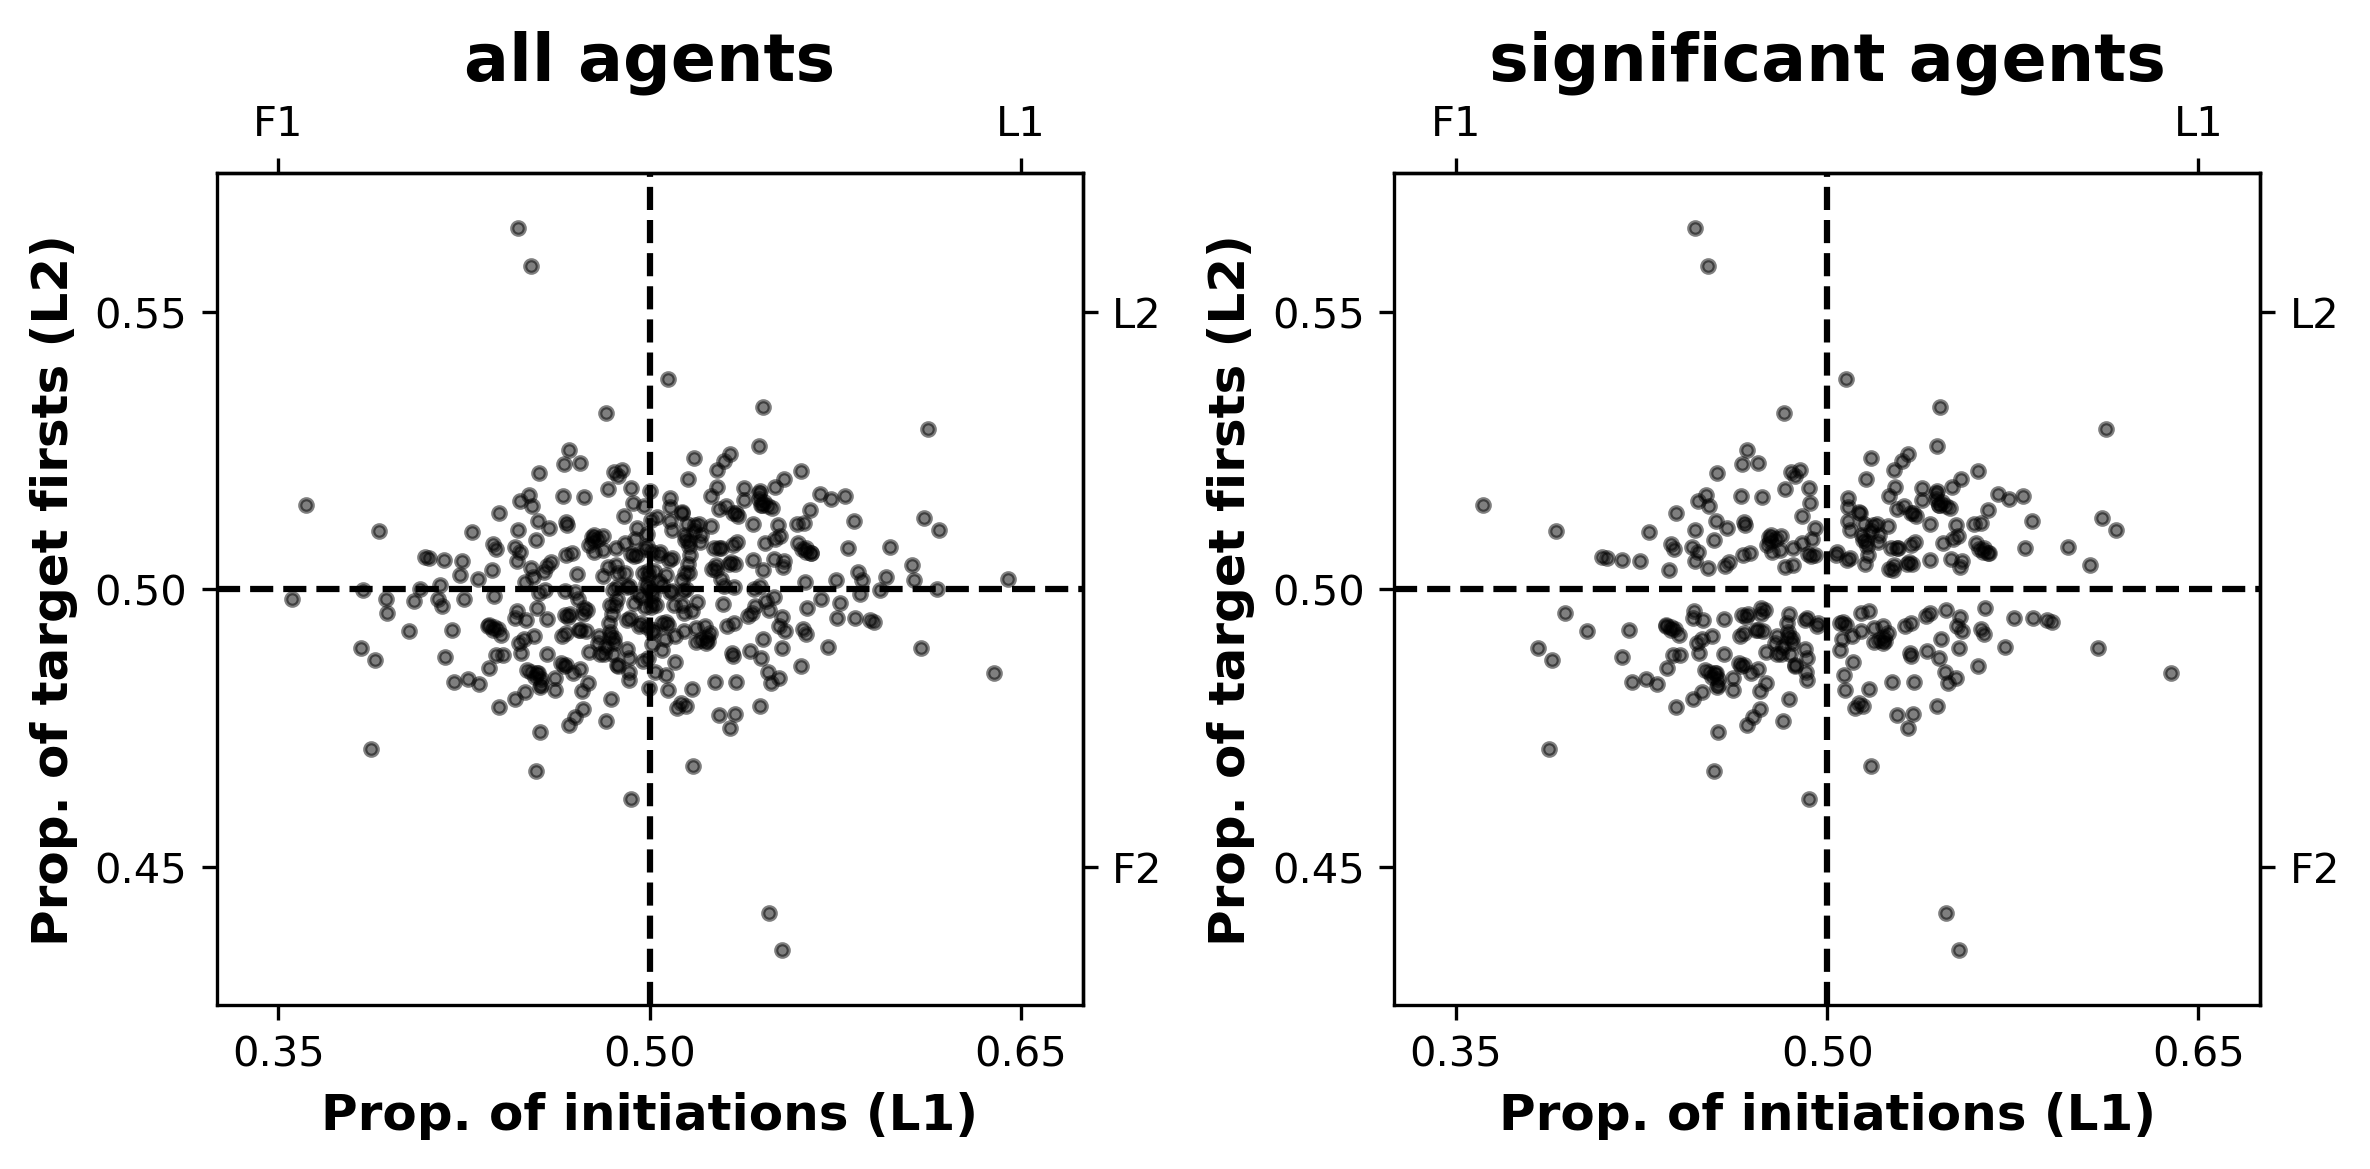

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4),  dpi = 300)

# Plotting your data (replace these with your actual arrays)
ax[0].plot(s1a1, s2a1, ".", alpha=0.5, color="k", label="a1")
ax[0].plot(s1a2, s2a2, ".", alpha=0.5, color="k", label="a2")

ax[1].plot(s1a1[tsig], s2a1[tsig], ".", alpha=0.5, color="k", label="a1")
ax[1].plot(s1a2[tsig], s2a2[tsig], ".", alpha=0.5, color="k", label="a2")

# Loop over each subplot to set up the axes
for i in range(2):
    # Add vertical and horizontal dashed lines at 0.5
    ax[i].axvline(0.5, color='k', linestyle='--')
    ax[i].axhline(0.5, color='k', linestyle='--')
    
    # Set limits for zoomed view
    ax[i].set_xlim(0.325, 0.675)
    ax[i].set_ylim(0.425, 0.575)
    ax[i].set_yticks([0.45, 0.5, 0.55])
    ax[i].set_xticks([0.35, 0.5, 0.65])
    
    # Set bottom and left labels and title
    ax[i].set_xlabel("Prop. of initiations (L1)", fontsize=12, weight='bold')
    ax[i].set_ylabel("Prop. of target firsts (L2)", fontsize=12, weight='bold')
    ax[i].set_title(["all agents", "significant agents"][i], fontsize=16, weight='bold')
    
    # Create secondary x-axis on the top and set its ticks:
    # At x=0.35 (left) label "F1" and x=0.65 (right) label "L1"
    secax_x = ax[i].secondary_xaxis('top')
    secax_x.set_xticks([0.35, 0.65])
    secax_x.set_xticklabels(["F1", "L1"])
    
    # Create secondary y-axis on the right and set its ticks:
    # At y=0.4 (bottom) label "F2" and y=0.6 (top) label "L2"
    secax_y = ax[i].secondary_yaxis('right')
    secax_y.set_yticks([0.45, 0.55])
    secax_y.set_yticklabels(["F2", "L2"])

plt.tight_layout()
plt.show()

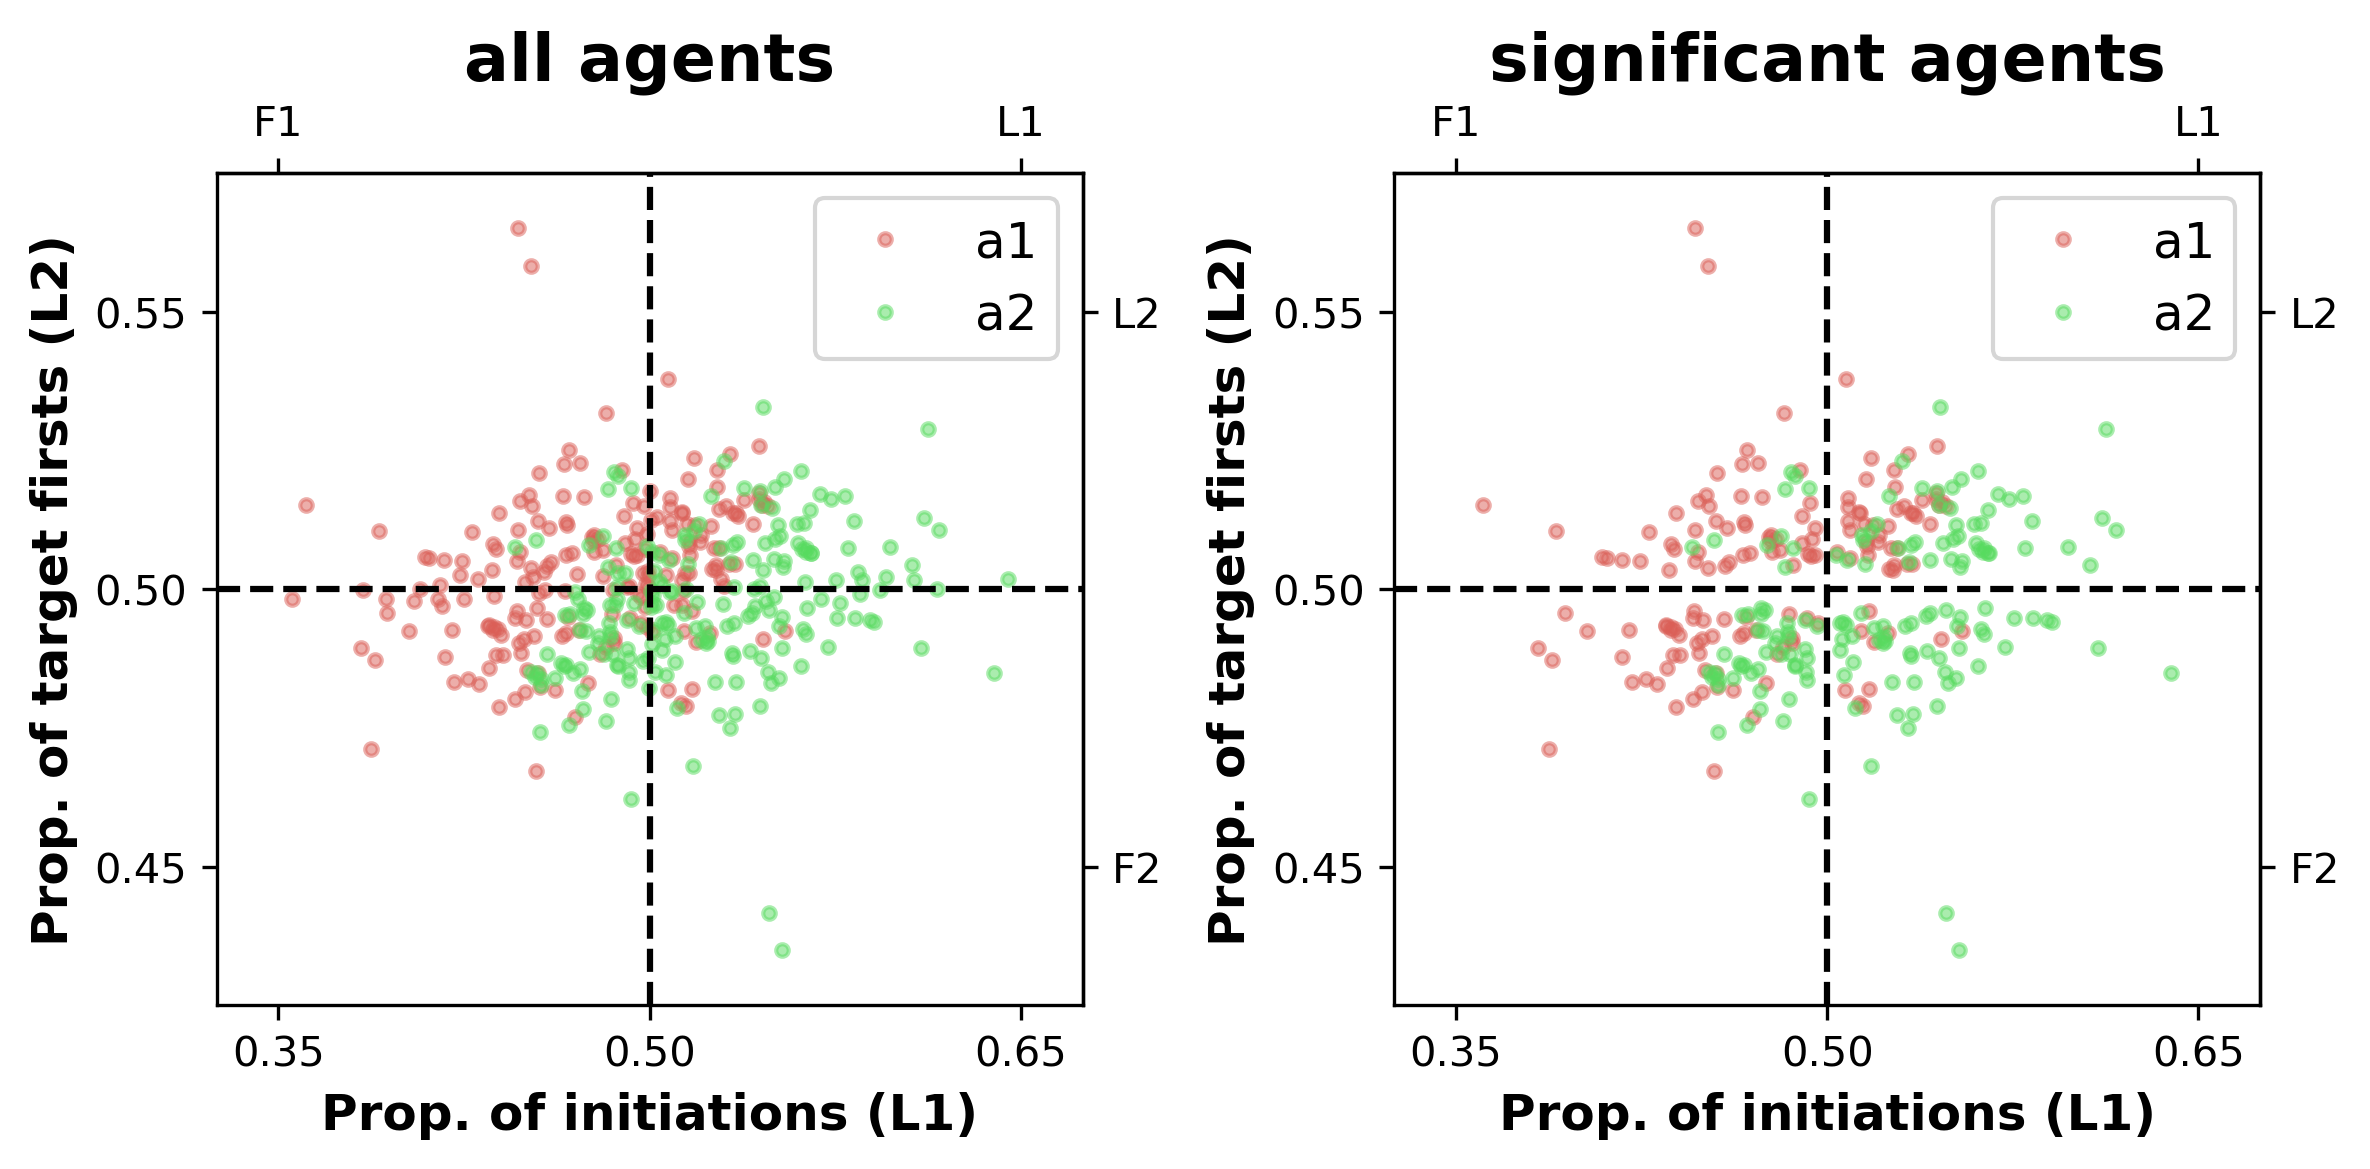

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), dpi = 300)

# Plotting your data (replace these with your actual arrays)
ax[0].plot(s1a1, s2a1, ".", alpha=0.5, color=mycols[0], label="a1")
ax[0].plot(s1a2, s2a2, ".", alpha=0.5, color=mycols[1], label="a2")

ax[1].plot(s1a1[tsig], s2a1[tsig], ".", alpha=0.5, color=mycols[0], label="a1")
ax[1].plot(s1a2[tsig], s2a2[tsig], ".", alpha=0.5, color=mycols[1], label="a2")

# Loop over each subplot to set up the axes
for i in range(2):
    # Add vertical and horizontal dashed lines at 0.5
    ax[i].axvline(0.5, color='k', linestyle='--')
    ax[i].axhline(0.5, color='k', linestyle='--')
    
    # Set limits for zoomed view
    ax[i].set_xlim(0.325, 0.675)
    ax[i].set_ylim(0.425, 0.575)
    ax[i].set_yticks([0.45, 0.5, 0.55])
    ax[i].set_xticks([0.35, 0.5, 0.65])
    
    # Set bottom and left labels and title
    ax[i].set_xlabel("Prop. of initiations (L1)", fontsize=12, weight='bold')
    ax[i].set_ylabel("Prop. of target firsts (L2)", fontsize=12, weight='bold')
    ax[i].set_title(["all agents", "significant agents"][i], fontsize=16, weight='bold')
    
    # Create secondary x-axis on the top and set its ticks:
    # At x=0.35 (left) label "F1" and x=0.65 (right) label "L1"
    secax_x = ax[i].secondary_xaxis('top')
    secax_x.set_xticks([0.35, 0.65])
    secax_x.set_xticklabels(["F1", "L1"])
    
    # Create secondary y-axis on the right and set its ticks:
    # At y=0.4 (bottom) label "F2" and y=0.6 (top) label "L2"
    secax_y = ax[i].secondary_yaxis('right')
    secax_y.set_yticks([0.45, 0.55])
    secax_y.set_yticklabels(["F2", "L2"])
    
    ax[i].legend(loc="upper right", fontsize=12)

plt.tight_layout()
plt.show()

In [17]:
s1, s2, s3 = test_strats

s1a1 = np.array([ s["a1"] / (s["a1"] + s["a2"]) for s in s1 ])
s1a2 = np.array([ s["a2"] / (s["a1"] + s["a2"]) for s in s1 ])

s3a1 = np.array([ s["a1"] / (s["a1"] + s["a2"]) for s in s3 ])
s3a2 = np.array([ s["a2"] / (s["a1"] + s["a2"]) for s in s3 ])

tsig = (test_sig.s1 < 0.01) & (test_sig.s3 < 0.01)

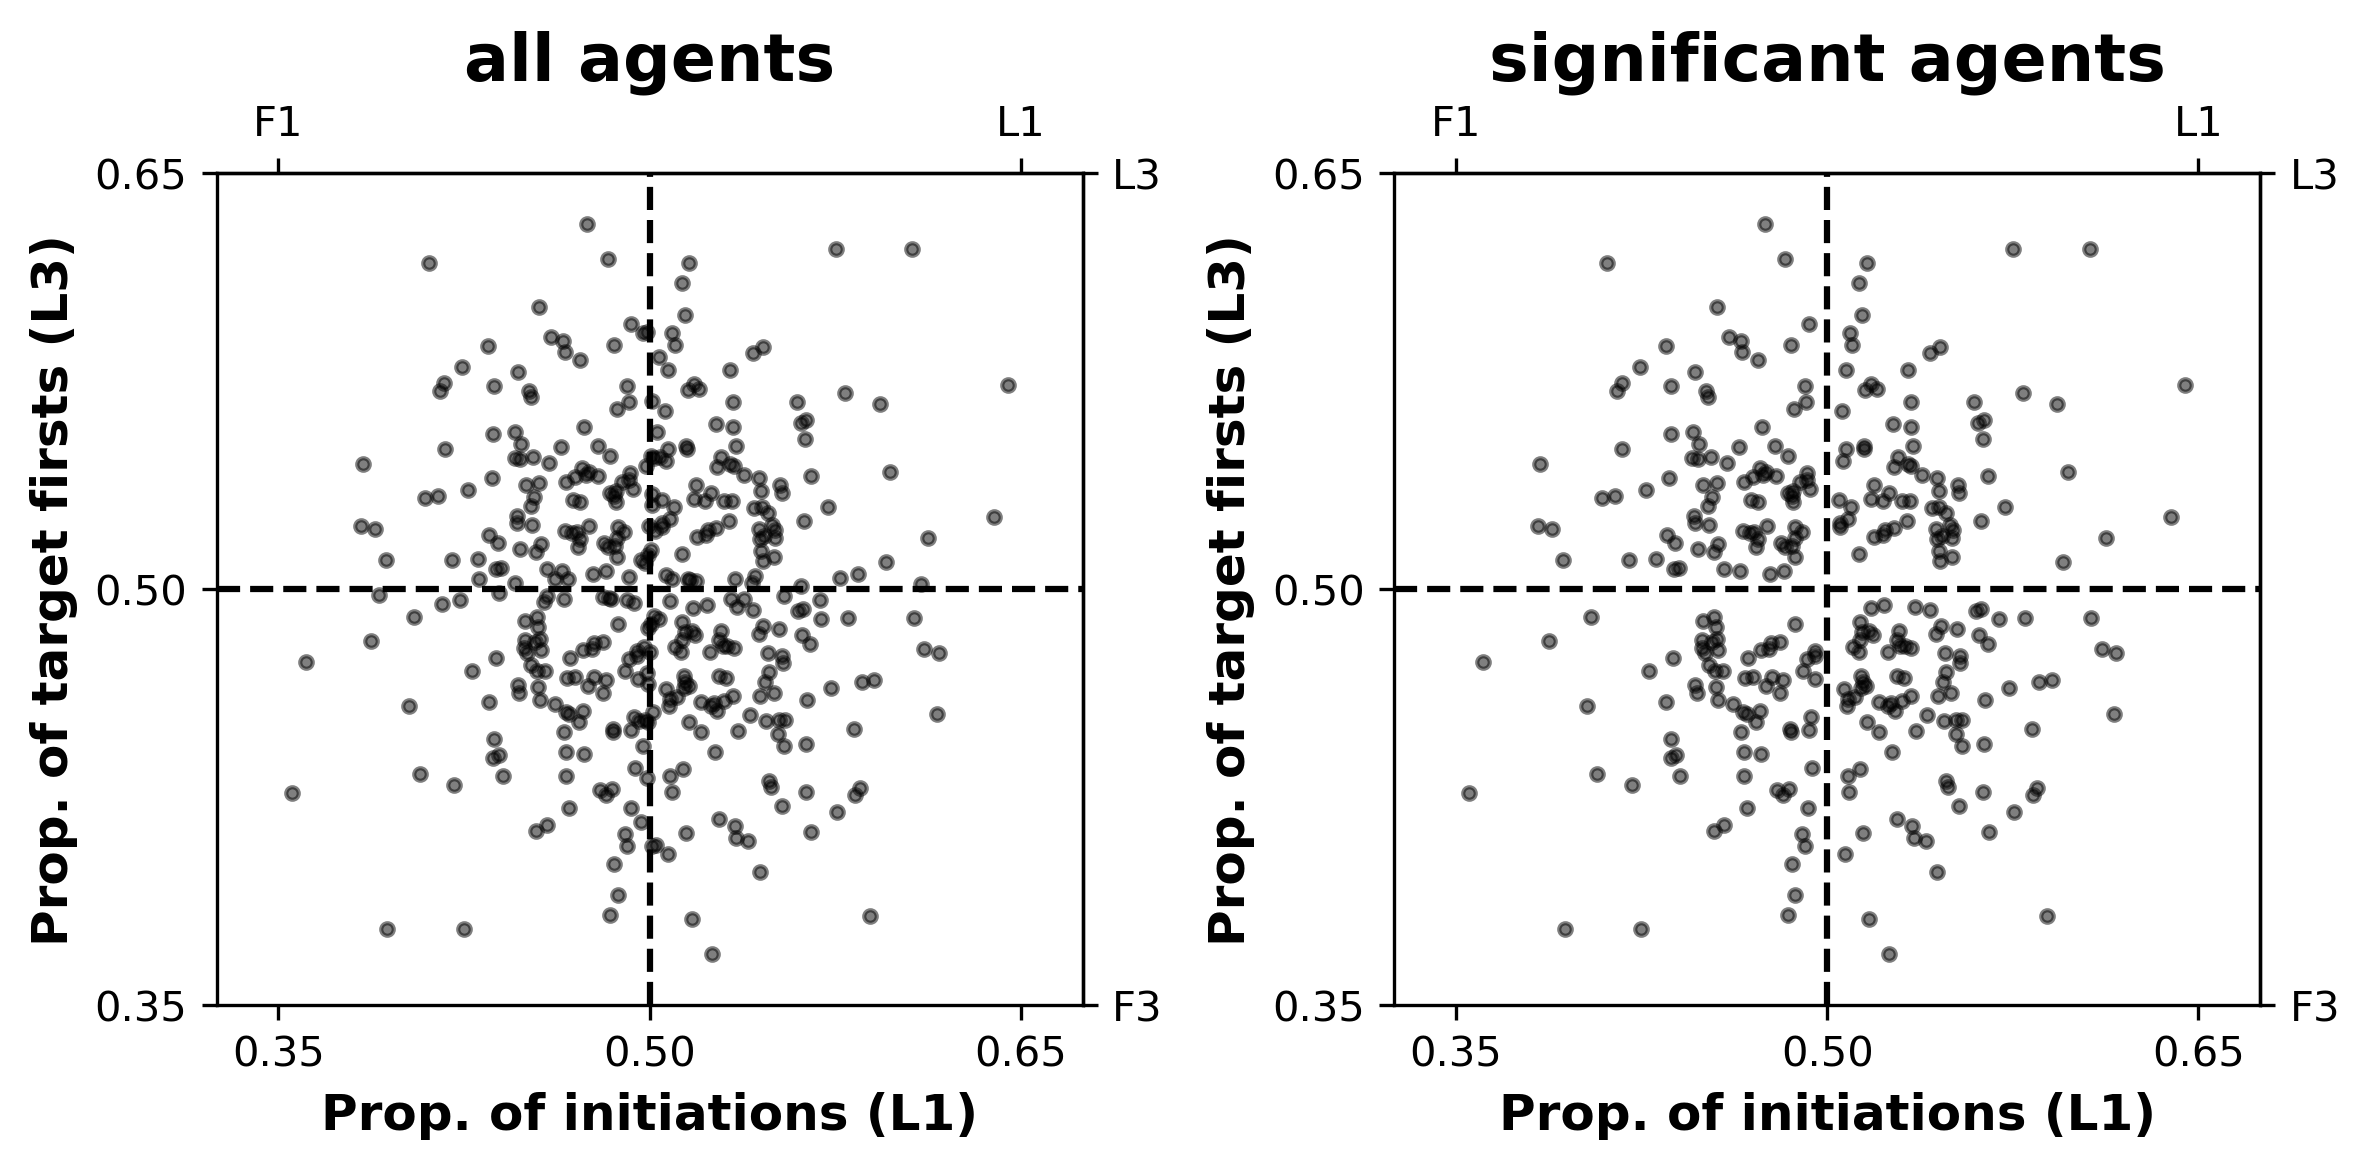

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4),  dpi = 300)

# Plotting your data (replace these with your actual arrays)
ax[0].plot(s1a1, s3a1, ".", alpha=0.5, color="k", label="a1")
ax[0].plot(s1a2, s3a2, ".", alpha=0.5, color="k", label="a2")

ax[1].plot(s1a1[tsig], s3a1[tsig], ".", alpha=0.5, color="k", label="a1")
ax[1].plot(s1a2[tsig], s3a2[tsig], ".", alpha=0.5, color="k", label="a2")

# Loop over each subplot to set up the axes
for i in range(2):
    # Add vertical and horizontal dashed lines at 0.5
    ax[i].axvline(0.5, color='k', linestyle='--')
    ax[i].axhline(0.5, color='k', linestyle='--')
    
    # Set limits for zoomed view
    ax[i].set_xlim(0.325, 0.675)
    ax[i].set_ylim(0.425, 0.575)
    ax[i].set_yticks([0.35, 0.5, 0.65])
    ax[i].set_xticks([0.35, 0.5, 0.65])
    
    # Set bottom and left labels and title
    ax[i].set_xlabel("Prop. of initiations (L1)", fontsize=12, weight='bold')
    ax[i].set_ylabel("Prop. of target firsts (L3)", fontsize=12, weight='bold')
    ax[i].set_title(["all agents", "significant agents"][i], fontsize=16, weight='bold')
    
    # Create secondary x-axis on the top and set its ticks:
    # At x=0.35 (left) label "F1" and x=0.65 (right) label "L1"
    secax_x = ax[i].secondary_xaxis('top')
    secax_x.set_xticks([0.35, 0.65])
    secax_x.set_xticklabels(["F1", "L1"])
    
    # Create secondary y-axis on the right and set its ticks:
    # At y=0.4 (bottom) label "F2" and y=0.6 (top) label "L2"
    secax_y = ax[i].secondary_yaxis('right')
    secax_y.set_yticks([0.35, 0.65])
    secax_y.set_yticklabels(["F3", "L3"])

plt.tight_layout()
plt.show()